In [76]:
#Extract packages
import pandas as pd
import numpy as np

In [77]:
#Extract dataset
df = pd.read_csv('https://raw.githubusercontent.com/HumayDS/Digital-Data-Analytics-E-15-24/refs/heads/main/clv.csv')

In [78]:
df.head()

,customer_id,first_purchase_date,last_purchase_date,total_orders,total_revenue
0,C001,2023-01-10,2023-03-15,5,250
1,C002,2023-02-05,2023-02-20,2,80
2,C003,2023-01-20,2023-06-10,10,900
3,C004,2023-03-01,2023-03-05,1,30
4,C005,2023-01-15,2023-04-20,6,300


In [79]:
#Identify and remove dublicate rows in the dataset
duplicates = df[df.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [customer_id, first_purchase_date, last_purchase_date, total_orders, total_revenue]
Index: []


In [80]:
#If exists drop it
df.drop_duplicates(inplace=True)

In [81]:
#Generete new column divide total_revenue to total orders
df['average_order_value'] = df['total_revenue'] / df['total_orders']

In [82]:
#Compute Correlation matrix

In [83]:
##Compute Correlation matrix
#Analyze relationship
numeric_df = df.select_dtypes(include='number')
correlation_matrix = numeric_df.corr()
print(correlation_matrix)

                     total_orders  total_revenue  average_order_value
total_orders             1.000000       0.979538             0.971470
total_revenue            0.979538       1.000000             0.965422
average_order_value      0.971470       0.965422             1.000000


In [84]:
#Sum of total orders or count
df['total_orders'].count()

np.int64(60)

In [85]:
#sum of total revenue
df['total_revenue'].sum()

np.int64(23037)

In [86]:
#Learn group by func
df.groupby('total_orders')['total_revenue'].sum()

,total_revenue
total_orders,
1,227
2,1035
3,1085
4,200
5,1470
6,2000
7,2120
8,2680
9,3220


In [87]:
#Sort ascending or descending
df.groupby('total_orders')['total_revenue'].sum().sort_values(ascending=False)

,total_revenue
total_orders,
12,3900
9,3220
10,2770
8,2680
11,2330
7,2120
6,2000
5,1470
3,1085


In [88]:
#Identify missing value
df.isnull().sum()

,0
customer_id,0
first_purchase_date,0
last_purchase_date,0
total_orders,0
total_revenue,0
average_order_value,0


In [89]:
#df['total_orders'] = df['total_orders'].fillna(df['total_orders'].median())
#df = df.dropna()

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          60 non-null     object 
 1   first_purchase_date  60 non-null     object 
 2   last_purchase_date   60 non-null     object 
 3   total_orders         60 non-null     int64  
 4   total_revenue        60 non-null     int64  
 5   average_order_value  60 non-null     float64
dtypes: float64(1), int64(2), object(3)
memory usage: 2.9+ KB


In [91]:
#convert first purchase date to datetime format

df['first_purchase_date'] = pd.to_datetime(df['first_purchase_date'])

In [92]:
#Extract month from first purchase date
df['first_purchase_month'] = df['first_purchase_date'].dt.month

In [93]:
df.head()

,customer_id,first_purchase_date,last_purchase_date,total_orders,total_revenue,average_order_value,first_purchase_month
0,C001,2023-01-10,2023-03-15,5,250,50.0,1
1,C002,2023-02-05,2023-02-20,2,80,40.0,2
2,C003,2023-01-20,2023-06-10,10,900,90.0,1
3,C004,2023-03-01,2023-03-05,1,30,30.0,3
4,C005,2023-01-15,2023-04-20,6,300,50.0,1


In [94]:
#group by first purchase date_month with total revenue
df.groupby('first_purchase_month')['total_revenue'].sum()

,total_revenue
first_purchase_month,
1,15960
2,5990
3,1087


In [95]:
# identify top orders customers
df.sort_values(by='total_orders', ascending=False).head()

,customer_id,first_purchase_date,last_purchase_date,total_orders,total_revenue,average_order_value,first_purchase_month
6,C007,2023-01-05,2023-07-01,12,1200,100.000000,1
30,C031,2023-01-04,2023-07-05,12,1300,108.333333,1
50,C051,2023-01-01,2023-07-12,12,1400,116.666667,1
17,C018,2023-01-03,2023-07-10,11,1150,104.545455,1
40,C041,2023-01-02,2023-07-08,11,1180,107.272727,1


In [96]:
#Check if there are any outliers in the dataset
df.describe().T

,count,mean,min,25%,50%,75%,max,std
first_purchase_date,60,2023-02-03 04:00:00,2023-01-01 00:00:00,2023-01-13 18:00:00,2023-02-01 12:00:00,2023-02-25 06:00:00,2023-03-15 00:00:00,NaN
total_orders,60.0,5.016667,1.0,2.0,4.5,8.0,12.0,3.427168
total_revenue,60.0,383.95,20.0,83.75,225.0,645.0,1400.0,381.303492
average_order_value,60.0,59.882552,20.0,40.0,50.0,83.125,116.666667,25.516719
first_purchase_month,60.0,1.716667,1.0,1.0,2.0,2.0,3.0,0.78312


#CLV - Customer lifetime value

##Customer Lifetime Value (CLV) is the total amount of revenue or profit a business expects to earn from a single customer over the entire duration of their relationship.
##CLV answers the question: “How much money will this customer bring to the business over time?”
##CLV is mainly driven by:
##Average Order Value (AOV) – how much a customer spends per purchase
##Purchase Frequency – how often they buy
##Customer Lifespan – how long they stay a customer

#CLV=Average Order Value×Purchase Frequency×Customer Lifespan

Example:

A customer spends $20 per purchase

Buys 2 times per month

Stays for 12 months

CLV = 20 × 2 × 12 = $480

Why CLV matters:

Helps determine how much you can spend on acquiring a customer

Identifies high-value customer segments

Supports retention strategies

Improves profitability analysis

In [97]:
# Recommendable check NA, outlier(describe(), and data types before analysing. )
#check if there is any na
df.isnull().sum()

,0
customer_id,0
first_purchase_date,0
last_purchase_date,0
total_orders,0
total_revenue,0
average_order_value,0
first_purchase_month,0


In [98]:
#df = df.dropna()

In [99]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
first_purchase_date,60,2023-02-03 04:00:00,2023-01-01 00:00:00,2023-01-13 18:00:00,2023-02-01 12:00:00,2023-02-25 06:00:00,2023-03-15 00:00:00,NaN
total_orders,60.0,5.016667,1.0,2.0,4.5,8.0,12.0,3.427168
total_revenue,60.0,383.95,20.0,83.75,225.0,645.0,1400.0,381.303492
average_order_value,60.0,59.882552,20.0,40.0,50.0,83.125,116.666667,25.516719
first_purchase_month,60.0,1.716667,1.0,1.0,2.0,2.0,3.0,0.78312


In [100]:
# Convert date columns to datetime format
df['first_purchase_date'] = pd.to_datetime(df['first_purchase_date'])
df['last_purchase_date'] = pd.to_datetime(df['last_purchase_date'])

In [101]:
# Calculate customer lifetime in days
# The total number of days the customer has been with us.
df['customer_lifetime'] = (df['last_purchase_date'] - df['first_purchase_date']).dt.days

In [102]:
# Calculate purchase frequency
#The average number of purchases a customer makes per day.
df['purchase_frequency'] = df['total_orders'] / df['customer_lifetime']

df

,customer_id,first_purchase_date,last_purchase_date,total_orders,total_revenue,average_order_value,first_purchase_month,customer_lifetime,purchase_frequency
0,C001,2023-01-10,2023-03-15,5,250,50.000000,1,64,0.078125
1,C002,2023-02-05,2023-02-20,2,80,40.000000,2,15,0.133333
2,C003,2023-01-20,2023-06-10,10,900,90.000000,1,141,0.070922
3,C004,2023-03-01,2023-03-05,1,30,30.000000,3,4,0.250000
4,C005,2023-01-15,2023-04-20,6,300,50.000000,1,95,0.063158
5,C006,2023-02-10,2023-02-12,1,20,20.000000,2,2,0.500000
6,C007,2023-01-05,2023-07-01,12,1200,100.000000,1,177,0.067797
7,C008,2023-03-12,2023-04-01,3,150,50.000000,3,20,0.150000
8,C009,2023-02-18,2023-05-30,7,500,71.428571,2,101,0.069307
9,C010,2023-01-25,2023-01-30,2,60,30.000000,1,5,0.400000


In [103]:
# Calculate average order value
#AOV (Average Order Value) calculates how much a customer spends on average per order.
df['average_order_value'] = df['total_revenue'] / df['total_orders']


In [104]:
df.head()

,customer_id,first_purchase_date,last_purchase_date,total_orders,total_revenue,average_order_value,first_purchase_month,customer_lifetime,purchase_frequency
0,C001,2023-01-10,2023-03-15,5,250,50.0,1,64,0.078125
1,C002,2023-02-05,2023-02-20,2,80,40.0,2,15,0.133333
2,C003,2023-01-20,2023-06-10,10,900,90.0,1,141,0.070922
3,C004,2023-03-01,2023-03-05,1,30,30.0,3,4,0.250000
4,C005,2023-01-15,2023-04-20,6,300,50.0,1,95,0.063158


In [105]:
#Determine for which period you want to calculate CLV.
future_days = 180  # for example, next 6 month

df['expected_orders'] = df['purchase_frequency'] * future_days

df['CLV'] = df['expected_orders'] * df['average_order_value']

In [106]:
margin = 0.3  # 30% margin

df['CLV'] = (
    df['average_order_value'] *
    df['purchase_frequency'] *
    future_days *
    margin
)

In [107]:
#Create segment (if not)
df['segment'] = pd.qcut(df['CLV'], q=3, labels=['Low', 'Medium', 'High'])

# Segment count
segment_counts = df['segment'].value_counts().sort_index()
print(segment_counts)


segment
Low       20
Medium    20
High      20
Name: count, dtype: int64


In [108]:
#This line segments customers into three groups based on their CLV values using quantile-based binning.
df['segment'] = pd.qcut(df['CLV'], q=3, labels=['Low', 'Medium', 'High'])

In [109]:
df

,customer_id,first_purchase_date,last_purchase_date,total_orders,total_revenue,average_order_value,first_purchase_month,customer_lifetime,purchase_frequency,expected_orders,CLV,segment
0,C001,2023-01-10,2023-03-15,5,250,50.000000,1,64,0.078125,14.062500,210.937500,Low
1,C002,2023-02-05,2023-02-20,2,80,40.000000,2,15,0.133333,24.000000,288.000000,Medium
2,C003,2023-01-20,2023-06-10,10,900,90.000000,1,141,0.070922,12.765957,344.680851,High
3,C004,2023-03-01,2023-03-05,1,30,30.000000,3,4,0.250000,45.000000,405.000000,High
4,C005,2023-01-15,2023-04-20,6,300,50.000000,1,95,0.063158,11.368421,170.526316,Low
5,C006,2023-02-10,2023-02-12,1,20,20.000000,2,2,0.500000,90.000000,540.000000,High
6,C007,2023-01-05,2023-07-01,12,1200,100.000000,1,177,0.067797,12.203390,366.101695,High
7,C008,2023-03-12,2023-04-01,3,150,50.000000,3,20,0.150000,27.000000,405.000000,High
8,C009,2023-02-18,2023-05-30,7,500,71.428571,2,101,0.069307,12.475248,267.326733,Medium
9,C010,2023-01-25,2023-01-30,2,60,30.000000,1,5,0.400000,72.000000,648.000000,High


<Axes: >

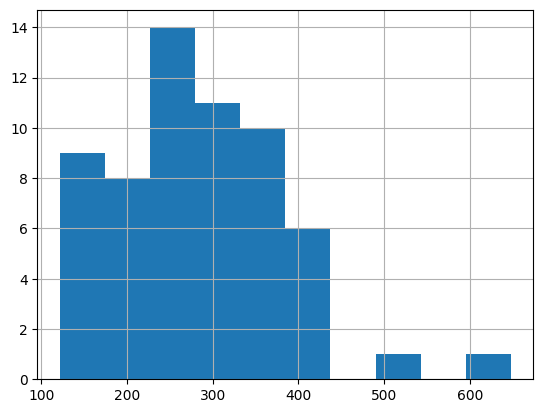

In [110]:
# use appropriate chart
df['CLV'].hist()

In [111]:
segment_analysis = df.groupby('segment').agg({
    'CLV': 'mean',
    'total_orders': 'mean',
    'total_revenue': 'mean',
    'customer_lifetime': 'mean',
    'purchase_frequency': 'mean'
}).round(2)

segment_analysis

/tmp/ipykernel_20909/930912433.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_analysis = df.groupby('segment').agg({


,CLV,total_orders,total_revenue,customer_lifetime,purchase_frequency
segment,,,,,
Low,184.36,3.90,229.35,66.50,0.07
Medium,277.95,5.15,383.00,73.85,0.10
High,391.29,6.00,539.50,80.80,0.15


#Interesting insight :
##Best customers are not frequent — they are long-term

CLV ↑ increases mainly due to lifetime and the number of orders.

As we move from Low → High:

Orders: 1.6 → 9.2
Lifetime: 11 → 144 days
 This means:
The main driver of CLV growth is not frequency, but longevity + order count.

Interesting and critical finding ❗

Purchase frequency DECREASES:

Low: 0.17
Medium: 0.08
High: 0.06

What does this mean?

High-value customers do not purchase frequently.

However, they stay longer and place more orders over time.
They are loyal, but not impulsive.

### Low CLV

Short-term, few orders

They come quickly and leave quickly
 Retention problem

### Medium CLV

Moderate behavior, stable customers
Upsell / growth potential

###High CLV

Stay for a long time, place many orders

But purchase frequency is low
Loyal customers, but need activation

In [112]:
#Churn and retention rate

In [113]:
import pandas as pd

data = {
    "month": ["Jan", "Feb", "Mar"],
    "start_users": [100, 120, 130],   # number of active users at the beginning of the month
    "new_users": [30, 40, 20],        # new users acquired during the month
    "end_users": [120, 130, 125]      # number of active users at the end of the month
}

df = pd.DataFrame(data)
print(df)

  month  start_users  new_users  end_users
0   Jan          100         30        120
1   Feb          120         40        130
2   Mar          130         20        125


In [114]:
# churned_users = start + new - end
df["churned_users"] = df["start_users"] + df["new_users"] - df["end_users"]

# churn rate (percentage of existing users who left)
df["churn_rate"] = df["churned_users"] / df["start_users"]

In [115]:
#retained_users = end_users - new_users
df["retained_users"] = df["end_users"] - df["new_users"]

df["retention_rate"] = df["retained_users"] / df["start_users"]